# Stress Testing — Portfolio Resilience Under Adverse Scenarios

## Business Context

A credit risk model built on historical data reflects the economic conditions of the period it was trained on. It does not know what happens when those conditions deteriorate sharply.

**Stress testing answers the question the PD model cannot:** how does our portfolio perform when the economy turns?

This is not a hypothetical exercise. Stress testing is a **regulatory requirement** under:
- **RBI's Internal Capital Adequacy Assessment Process (ICAAP)** — banks must demonstrate capital adequacy under stress
- **Basel III Pillar 2** — requires institutions to hold capital buffers against tail risks
- **SR 11-7** — requires ongoing monitoring of model performance under changing conditions

In practice, a bank's risk function runs stress tests quarterly — before board risk committee meetings and before submitting capital plans to the regulator. The outputs directly influence capital buffer decisions, provisioning levels, and credit policy tightening.

## Stress Scenarios

Three macro scenarios are simulated, calibrated to realistic Indian banking stress events:

| Scenario | PD Multiplier | LGD Shock | Basis |
|----------|--------------|-----------|-------|
| **Baseline** | 1.0× | 0% | Current model output |
| **Mild Stress** | 1.5× | +5pp | Moderate slowdown — GDP growth drops to ~4%, credit costs rise |
| **Severe Stress** | 2.5× | +15pp | Severe recession — 2008-style credit event or COVID-19 impact |
| **Extreme Stress** | 4.0× | +25pp | Tail risk — NPA crisis, systemic shock (calibrated to IL&FS-type event) |

## What Stress Testing Reveals

1. **Capital adequacy** — does the bank remain above minimum CET1 under each scenario?
2. **EL escalation** — how much do provisioning requirements increase?
3. **RAROC collapse** — which risk bands become value-destructive under stress?
4. **Strategy resilience** — which lending strategy best preserves capital under stress?
5. **Break-even PD** — at what stress multiplier does each strategy cross below the hurdle rate?

## Inputs
- `../01_data/processed/strategy_output.csv` — loan-level dataset with strategy decisions
- `../05_decision_engine/strategy_comparison.csv` — baseline strategy metrics

## Outputs
- `../01_data/processed/stress_output.csv` — loan-level stressed metrics
- `../06_stress_testing/stress_summary.csv` — scenario × strategy results matrix

---
## 1. Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
import os

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120

os.makedirs("../06_stress_testing", exist_ok=True)

print("Libraries loaded.")

Libraries loaded.


---
## 2. Load Data and Define Scenarios

In [2]:
df = pd.read_csv("../01_data/processed/strategy_output.csv")

print(f"Portfolio loaded: {len(df):,} loans")
print(f"Columns: {list(df.columns)}")
print(f"\nBaseline portfolio:")
print(f"  Mean PD   : {df['PD'].mean():.2%}")
print(f"  Total EAD : ₹{df['EAD'].sum():,.0f}")
print(f"  Total EL  : ₹{df['EL'].sum():,.0f}")

Portfolio loaded: 61,503 loans
Columns: ['ACTUAL_DEFAULT', 'PD', 'RISK_BAND', 'CREDIT_SCORE', 'RISK_GRADE', 'EAD', 'EL', 'EL_RATE', 'ECON_CAPITAL', 'RAROC', 'VALUE_DECISION', 'APPROVED_A', 'APPROVED_B', 'APPROVED_C', 'APPROVED_D', 'RATE_D', 'RAROC_D']

Baseline portfolio:
  Mean PD   : 40.25%
  Total EAD : ₹36,596,538,405
  Total EL  : ₹6,403,623,086


In [3]:
# ── SCENARIO DEFINITIONS ──────────────────────────────────────────────────────

SCENARIOS = {
    "Baseline"      : {"pd_mult": 1.0, "lgd_add": 0.00,  "color": "#1565C0"},
    "Mild Stress"   : {"pd_mult": 1.5, "lgd_add": 0.05,  "color": "#FDD835"},
    "Severe Stress" : {"pd_mult": 2.5, "lgd_add": 0.15,  "color": "#FB8C00"},
    "Extreme Stress": {"pd_mult": 4.0, "lgd_add": 0.25,  "color": "#E53935"},
}

# ── STRATEGY DEFINITIONS ──────────────────────────────────────────────────────
STRATEGIES = {
    "Aggressive"         : "APPROVED_A",
    "Conservative"       : "APPROVED_B",
    "RAROC Gated"        : "APPROVED_C",
    "Risk-Based Pricing" : "APPROVED_D",
}

# ── FINANCIAL PARAMETERS (carried from notebook 04/05) ────────────────────────
RISK_WEIGHTS   = {1: 0.75, 2: 0.75, 3: 1.00, 4: 1.50, 5: 1.50}
CAPITAL_RATIO  = 0.105
INTEREST_RATE  = 0.12
OPERATING_COST = 0.03
HURDLE_RATE    = 0.14
LGD_BASE       = 0.45

# Risk-based pricing rate schedule (Strategy D)
RATE_SCHEDULE  = {1: 0.10, 2: 0.12, 3: 0.16, 4: 0.22, 5: 0.28}

band_labels = {1: "Very Low", 2: "Low", 3: "Medium", 4: "High", 5: "Very High"}

print("Scenarios defined:")
for name, params in SCENARIOS.items():
    print(f"  {name:<18}: PD × {params['pd_mult']:.1f}  |  LGD + {params['lgd_add']:.0%}")

Scenarios defined:
  Baseline          : PD × 1.0  |  LGD + 0%
  Mild Stress       : PD × 1.5  |  LGD + 5%
  Severe Stress     : PD × 2.5  |  LGD + 15%
  Extreme Stress    : PD × 4.0  |  LGD + 25%


---
## 3. Apply Stress Scenarios — Loan-Level Recalculation

For each scenario, PD is scaled by the multiplier (capped at 100%) and LGD is shifted upward (capped at 100%). All downstream financial metrics — EL, RWA, capital, RAROC — are recomputed from the stressed inputs.

**Why cap PD at 100%?** PD represents a probability — it cannot exceed 1. In extreme stress, many borrowers in Band 4–5 will hit the 100% cap, reflecting the reality that under systemic stress, high-risk borrowers approach near-certain default.

In [4]:
def apply_stress(df, pd_mult, lgd_add, rate_col="INTEREST_RATE"):
    """
    Apply a stress scenario to the loan portfolio.
    Returns a copy of df with stressed financial metrics.
    """
    s = df.copy()

    # Stressed PD and LGD — capped at 1.0
    s["PD_STRESSED"]  = (s["PD"] * pd_mult).clip(upper=1.0)
    s["LGD_STRESSED"] = min(LGD_BASE + lgd_add, 1.0)

    # Stressed EL
    s["EL_STRESSED"]      = s["PD_STRESSED"] * s["LGD_STRESSED"] * s["EAD"]
    s["EL_RATE_STRESSED"] = s["PD_STRESSED"] * s["LGD_STRESSED"]

    # RWA and capital unchanged (risk weights are regulatory floors, not PD-linked in standardised)
    s["RWA_STRESSED"]     = s["EAD"] * s["RISK_BAND"].map(RISK_WEIGHTS)
    s["CAPITAL_STRESSED"] = s["RWA_STRESSED"] * CAPITAL_RATIO

    # RAROC under stress — flat rate
    revenue       = s["EAD"] * INTEREST_RATE
    opex          = s["EAD"] * OPERATING_COST
    net_income    = revenue - s["EL_STRESSED"] - opex
    s["RAROC_STRESSED"] = np.where(
        s["CAPITAL_STRESSED"] > 0,
        net_income / s["CAPITAL_STRESSED"],
        0
    )

    # RAROC under stress — risk-based pricing (Strategy D)
    revenue_rbp   = s["EAD"] * s["RISK_BAND"].map(RATE_SCHEDULE)
    net_income_rbp = revenue_rbp - s["EL_STRESSED"] - opex
    s["RAROC_STRESSED_RBP"] = np.where(
        s["CAPITAL_STRESSED"] > 0,
        net_income_rbp / s["CAPITAL_STRESSED"],
        0
    )

    return s

# Store stressed portfolios
stressed = {}
for scenario, params in SCENARIOS.items():
    stressed[scenario] = apply_stress(df, params["pd_mult"], params["lgd_add"])

print("Stress scenarios applied. Checking PD escalation:")
for scenario in SCENARIOS:
    s = stressed[scenario]
    print(f"  {scenario:<18}: Mean PD = {s['PD_STRESSED'].mean():.2%}  "
          f"| PD capped at 100%: {(s['PD_STRESSED'] >= 1.0).sum():,} loans")

Stress scenarios applied. Checking PD escalation:
  Baseline          : Mean PD = 40.25%  | PD capped at 100%: 0 loans
  Mild Stress       : Mean PD = 58.63%  | PD capped at 100%: 7,872 loans
  Severe Stress     : Mean PD = 79.05%  | PD capped at 100%: 28,323 loans
  Extreme Stress    : Mean PD = 91.18%  | PD capped at 100%: 44,530 loans


---
## 4. Scenario × Strategy Results Matrix

The full stress matrix — every scenario against every strategy. This is the primary output regulators and risk committees review: how does each lending policy hold up as conditions deteriorate?

In [5]:
def stressed_strategy_metrics(s_df, approved_col, use_rbp=False):
    """Compute portfolio metrics for an approved subset under stress."""
    subset = s_df[s_df[approved_col]].copy()
    if len(subset) == 0:
        return None

    raroc_col = "RAROC_STRESSED_RBP" if use_rbp else "RAROC_STRESSED"
    total_ead     = subset["EAD"].sum()
    total_el      = subset["EL_STRESSED"].sum()
    total_capital = subset["CAPITAL_STRESSED"].sum()

    revenue = subset["EAD"] * (subset["RISK_BAND"].map(RATE_SCHEDULE) if use_rbp else INTEREST_RATE)
    opex    = subset["EAD"] * OPERATING_COST
    net_income = revenue.sum() - total_el - opex.sum()

    return {
        "Loans"          : len(subset),
        "Total_EAD"      : total_ead,
        "Mean_PD_Stress" : subset["PD_STRESSED"].mean(),
        "Total_EL"       : total_el,
        "EL_Rate"        : total_el / total_ead,
        "Total_Capital"  : total_capital,
        "Portfolio_RAROC": net_income / total_capital if total_capital > 0 else 0,
        "Net_Income"     : net_income,
        "Capital_Breach" : net_income < 0,   # True if portfolio is loss-making under stress
    }

# Build full matrix
matrix_rows = []
for scenario in SCENARIOS:
    s_df = stressed[scenario]
    for strat_name, approved_col in STRATEGIES.items():
        use_rbp = (strat_name == "Risk-Based Pricing")
        m = stressed_strategy_metrics(s_df, approved_col, use_rbp)
        if m:
            matrix_rows.append({
                "Scenario" : scenario,
                "Strategy" : strat_name,
                **m
            })

matrix_df = pd.DataFrame(matrix_rows)

# Display RAROC matrix
raroc_pivot = matrix_df.pivot(index="Scenario", columns="Strategy", values="Portfolio_RAROC") * 100
raroc_pivot = raroc_pivot.reindex(["Baseline", "Mild Stress", "Severe Stress", "Extreme Stress"])

print("PORTFOLIO RAROC UNDER STRESS (%) — SCENARIO × STRATEGY MATRIX")
print("=" * 80)
print(raroc_pivot.round(2).to_string())
print("=" * 80)
print(f"Hurdle rate: {HURDLE_RATE:.0%} | Values below hurdle = value destructive under stress")

PORTFOLIO RAROC UNDER STRESS (%) — SCENARIO × STRATEGY MATRIX
Strategy        Aggressive  Conservative  RAROC Gated  Risk-Based Pricing
Scenario                                                                 
Baseline             -7.08         71.03        36.15               47.32
Mild Stress         -56.25         42.19        -0.84               -1.85
Severe Stress      -179.19        -29.90       -93.32             -124.79
Extreme Stress     -352.37       -154.87      -253.62             -297.97
Hurdle rate: 14% | Values below hurdle = value destructive under stress


In [6]:
# EL escalation matrix
el_pivot = matrix_df.pivot(index="Scenario", columns="Strategy", values="EL_Rate") * 100
el_pivot  = el_pivot.reindex(["Baseline", "Mild Stress", "Severe Stress", "Extreme Stress"])

print("PORTFOLIO EL RATE UNDER STRESS (%) — SCENARIO × STRATEGY MATRIX")
print("=" * 80)
print(el_pivot.round(2).to_string())
print("=" * 80)

# Capital breach flags
breach_pivot = matrix_df.pivot(index="Scenario", columns="Strategy", values="Capital_Breach")
breach_pivot = breach_pivot.reindex(["Baseline", "Mild Stress", "Severe Stress", "Extreme Stress"])

print("\nCAPITAL BREACH FLAGS (True = portfolio net loss under scenario)")
print("=" * 80)
print(breach_pivot.to_string())
print("=" * 80)

PORTFOLIO EL RATE UNDER STRESS (%) — SCENARIO × STRATEGY MATRIX
Strategy        Aggressive  Conservative  RAROC Gated  Risk-Based Pricing
Scenario                                                                 
Baseline              9.96          3.41         5.45                9.96
Mild Stress          16.59          5.68         9.08               16.59
Severe Stress        33.18         11.35        18.16               33.18
Extreme Stress       56.56         21.20        33.91               56.56

CAPITAL BREACH FLAGS (True = portfolio net loss under scenario)
Strategy        Aggressive  Conservative  RAROC Gated  Risk-Based Pricing
Scenario                                                                 
Baseline              True         False        False               False
Mild Stress           True         False         True                True
Severe Stress         True          True         True                True
Extreme Stress        True          True         True    

---
## 5. EL Escalation — How Losses Build Under Stress

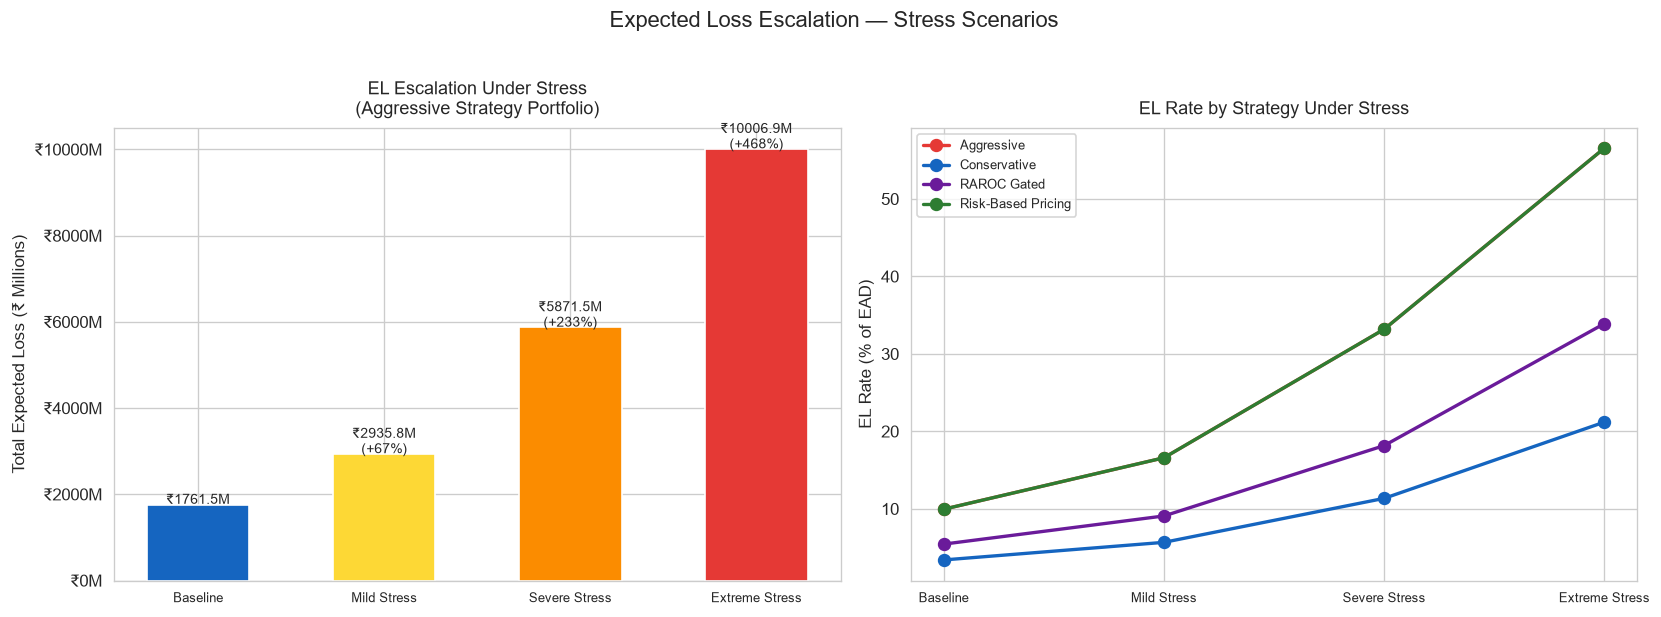

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

scenario_names = list(SCENARIOS.keys())
scenario_colors = [SCENARIOS[s]["color"] for s in scenario_names]
strategy_list   = list(STRATEGIES.keys())

# ── Plot 1: EL escalation by scenario (full portfolio — aggressive) ──
el_vals_agg = [
    stressed[sc][stressed[sc]["APPROVED_A"]]["EL_STRESSED"].sum() / 1e6
    for sc in scenario_names
]
el_base = el_vals_agg[0]

bars = axes[0].bar(scenario_names, el_vals_agg, color=scenario_colors,
                   edgecolor="white", width=0.55)
for bar, val in zip(bars, el_vals_agg):
    pct_increase = (val / el_base - 1) * 100
    label = f"₹{val:.1f}M" if val == el_base else f"₹{val:.1f}M\n(+{pct_increase:.0f}%)"
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + el_base * 0.01,
                 label, ha="center", fontsize=8.5)

axes[0].set_ylabel("Total Expected Loss (₹ Millions)")
axes[0].set_title("EL Escalation Under Stress\n(Aggressive Strategy Portfolio)",
                  fontsize=11, pad=8)
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"₹{x:.0f}M"))
axes[0].tick_params(axis="x", labelsize=8)

# ── Plot 2: EL rate by scenario and strategy ──
x = np.arange(len(scenario_names))
w = 0.2
strat_colors = ["#E53935", "#1565C0", "#6A1B9A", "#2E7D32"]
approved_cols = ["APPROVED_A", "APPROVED_B", "APPROVED_C", "APPROVED_D"]

for i, (strat, approved_col, sc) in enumerate(
    zip(strategy_list, approved_cols, strat_colors)
):
    el_rates = [
        stressed[scen][stressed[scen][approved_col]]["EL_STRESSED"].sum() /
        stressed[scen][stressed[scen][approved_col]]["EAD"].sum() * 100
        for scen in scenario_names
    ]
    axes[1].plot(scenario_names, el_rates, marker="o", color=sc,
                 lw=2, markersize=7, label=strat)

axes[1].set_ylabel("EL Rate (% of EAD)")
axes[1].set_title("EL Rate by Strategy Under Stress", fontsize=11, pad=8)
axes[1].legend(fontsize=8)
axes[1].tick_params(axis="x", labelsize=8)

plt.suptitle("Expected Loss Escalation — Stress Scenarios", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 6. RAROC Collapse — Value Destruction Under Stress

As stress intensifies, RAROC falls. The critical question is: at which scenario does each strategy cross below the hurdle rate — the point at which the bank is no longer creating value and should have tightened credit policy?

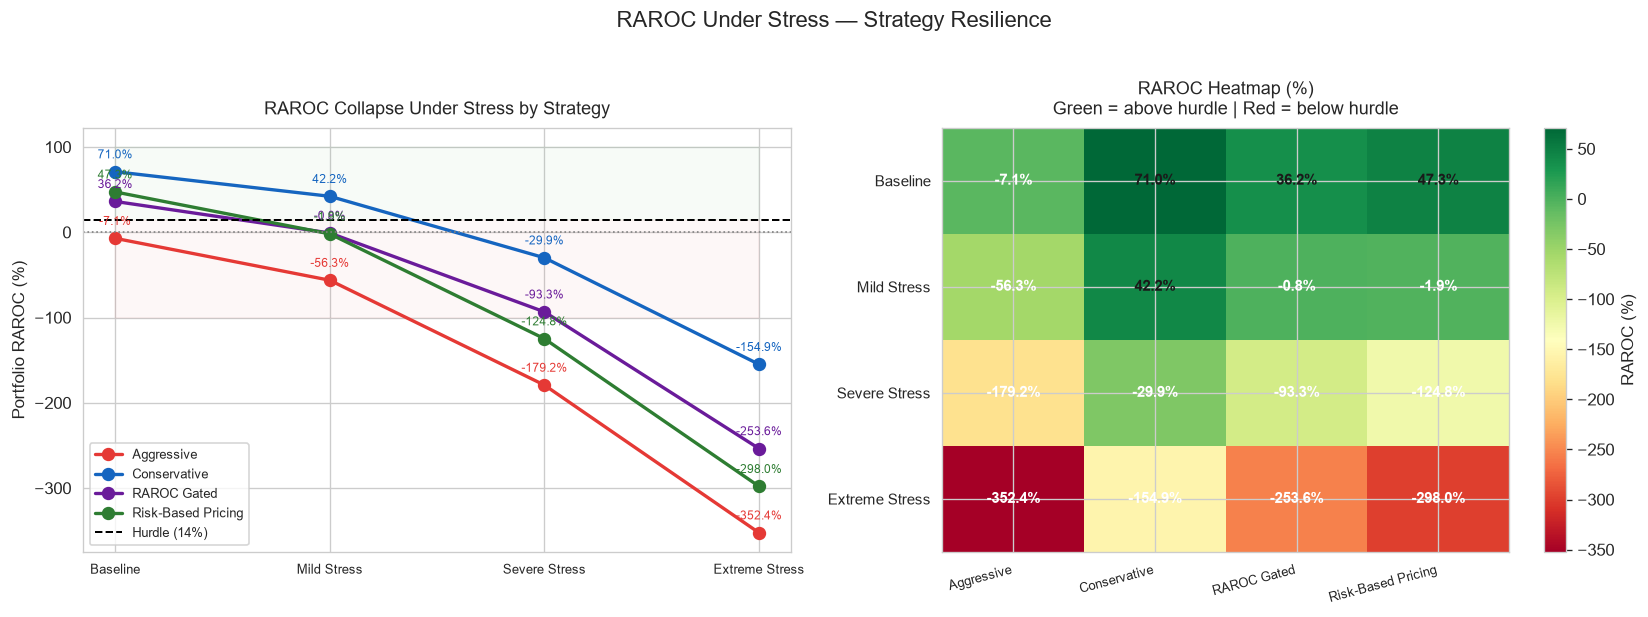

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

approved_cols_map = {
    "Aggressive"         : ("APPROVED_A", False),
    "Conservative"       : ("APPROVED_B", False),
    "RAROC Gated"        : ("APPROVED_C", False),
    "Risk-Based Pricing" : ("APPROVED_D", True),
}

# ── Plot 1: RAROC trajectory by strategy ──
for strat, (approved_col, use_rbp) in approved_cols_map.items():
    color = strat_colors[list(approved_cols_map.keys()).index(strat)]
    raroc_vals = []
    for scen in scenario_names:
        s_df   = stressed[scen]
        subset = s_df[s_df[approved_col]]
        rev    = subset["EAD"] * (subset["RISK_BAND"].map(RATE_SCHEDULE) if use_rbp else INTEREST_RATE)
        opex   = subset["EAD"] * OPERATING_COST
        ni     = rev.sum() - subset["EL_STRESSED"].sum() - opex.sum()
        cap    = subset["CAPITAL_STRESSED"].sum()
        raroc_vals.append((ni / cap * 100) if cap > 0 else 0)

    axes[0].plot(scenario_names, raroc_vals, marker="o", color=color,
                 lw=2, markersize=7, label=strat)
    for i, (scen, val) in enumerate(zip(scenario_names, raroc_vals)):
        axes[0].annotate(f"{val:.1f}%", (scen, val),
                         textcoords="offset points", xytext=(0, 8),
                         ha="center", fontsize=7, color=color)

axes[0].axhline(HURDLE_RATE * 100, color="black", linestyle="--", lw=1.2,
                label=f"Hurdle ({HURDLE_RATE:.0%})")
axes[0].axhline(0, color="gray", linestyle=":", lw=1)
axes[0].fill_between(scenario_names, HURDLE_RATE*100, 100,
                     alpha=0.04, color="#43A047")
axes[0].fill_between(scenario_names, -100, HURDLE_RATE*100,
                     alpha=0.04, color="#E53935")
axes[0].set_ylabel("Portfolio RAROC (%)")
axes[0].set_title("RAROC Collapse Under Stress by Strategy", fontsize=11, pad=8)
axes[0].legend(fontsize=8)
axes[0].tick_params(axis="x", labelsize=8)

# ── Plot 2: Heatmap — RAROC matrix ──
raroc_heat = raroc_pivot.copy()
im = axes[1].imshow(
    raroc_heat.values.astype(float),
    cmap="RdYlGn", aspect="auto",
    vmin=raroc_heat.values.astype(float).min(),
    vmax=max(raroc_heat.values.astype(float).max(), HURDLE_RATE * 100 + 5)
)

axes[1].set_xticks(range(len(raroc_heat.columns)))
axes[1].set_xticklabels(raroc_heat.columns, rotation=15, ha="right", fontsize=8)
axes[1].set_yticks(range(len(raroc_heat.index)))
axes[1].set_yticklabels(raroc_heat.index, fontsize=9)
axes[1].set_title("RAROC Heatmap (%)\nGreen = above hurdle | Red = below hurdle",
                  fontsize=11, pad=8)

for i in range(len(raroc_heat.index)):
    for j in range(len(raroc_heat.columns)):
        val = float(raroc_heat.values[i, j])
        axes[1].text(j, i, f"{val:.1f}%",
                     ha="center", va="center",
                     fontsize=9, fontweight="bold",
                     color="white" if val < HURDLE_RATE * 100 else "#1a1a1a")

plt.colorbar(im, ax=axes[1], label="RAROC (%)")
plt.suptitle("RAROC Under Stress — Strategy Resilience", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 7. Risk Band Behaviour Under Stress

Not all risk bands respond equally to stress. Band 1–2 borrowers have low baseline PD — even a 4× multiplier may leave them below the 100% cap. Band 4–5 borrowers at 4× stress will be at or near 100% PD — near-certain default. This section examines how each band's EL and RAROC evolves across scenarios.

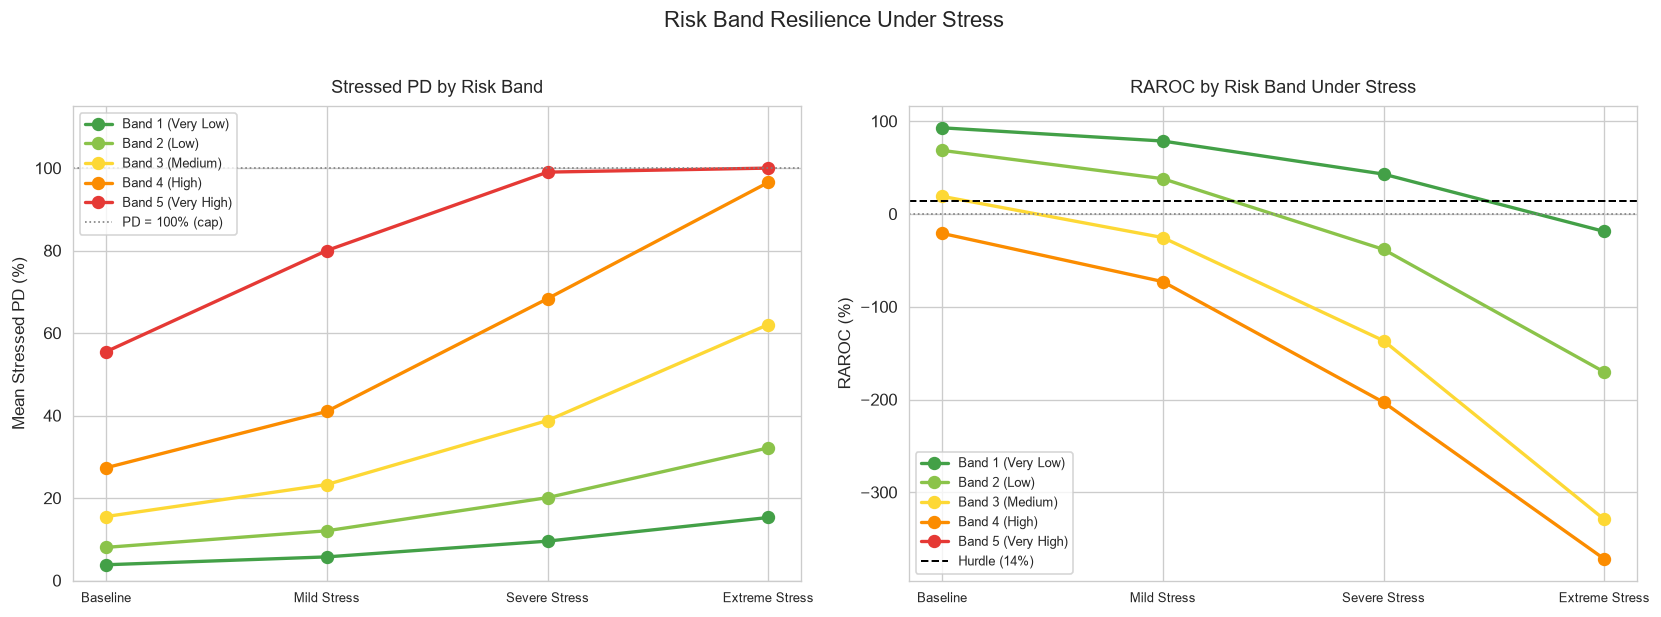

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
band_colors = ["#43A047", "#8BC34A", "#FDD835", "#FB8C00", "#E53935"]

# ── Plot 1: Mean stressed PD per band across scenarios ──
for b, bc in zip([1, 2, 3, 4, 5], band_colors):
    pd_by_scenario = [
        stressed[sc].loc[stressed[sc]["RISK_BAND"] == b, "PD_STRESSED"].mean() * 100
        for sc in scenario_names
    ]
    axes[0].plot(scenario_names, pd_by_scenario, marker="o", color=bc,
                 lw=2, markersize=7, label=f"Band {b} ({band_labels[b]})")

axes[0].axhline(100, color="gray", linestyle=":", lw=1, label="PD = 100% (cap)")
axes[0].set_ylabel("Mean Stressed PD (%)")
axes[0].set_title("Stressed PD by Risk Band", fontsize=11, pad=8)
axes[0].legend(fontsize=8)
axes[0].tick_params(axis="x", labelsize=8)
axes[0].set_ylim(0, 115)

# ── Plot 2: RAROC per band under each scenario (aggressive strategy subset) ──
for b, bc in zip([1, 2, 3, 4, 5], band_colors):
    raroc_by_scenario = []
    for sc in scenario_names:
        s_df   = stressed[sc]
        subset = s_df[(s_df["RISK_BAND"] == b) & (s_df["APPROVED_A"])]
        if len(subset) == 0:
            raroc_by_scenario.append(np.nan)
            continue
        rev    = subset["EAD"] * INTEREST_RATE
        opex   = subset["EAD"] * OPERATING_COST
        ni     = rev - subset["EL_STRESSED"] - opex
        cap    = subset["CAPITAL_STRESSED"]
        raroc_by_scenario.append(
            (ni.sum() / cap.sum() * 100) if cap.sum() > 0 else 0
        )
    axes[1].plot(scenario_names, raroc_by_scenario, marker="o", color=bc,
                 lw=2, markersize=7, label=f"Band {b} ({band_labels[b]})")

axes[1].axhline(HURDLE_RATE * 100, color="black", linestyle="--", lw=1.2,
                label=f"Hurdle ({HURDLE_RATE:.0%})")
axes[1].axhline(0, color="gray", linestyle=":", lw=1)
axes[1].set_ylabel("RAROC (%)")
axes[1].set_title("RAROC by Risk Band Under Stress", fontsize=11, pad=8)
axes[1].legend(fontsize=8)
axes[1].tick_params(axis="x", labelsize=8)

plt.suptitle("Risk Band Resilience Under Stress", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 8. Capital Adequacy — Does the Bank Remain Solvent?

The ultimate stress test question: does the bank's capital hold? This section computes the **capital buffer consumed** under each scenario and flags the point at which net income turns negative — implying capital erosion and a potential regulatory breach.

In [10]:
print("CAPITAL ADEQUACY UNDER STRESS — AGGRESSIVE STRATEGY")
print("=" * 75)
print(f"{'Scenario':<20} {'Total EL (₹M)':>15} {'Total Capital (₹M)':>20} "
      f"{'Net Income (₹M)':>17} {'Capital Status':>15}")
print("-" * 75)

for sc in scenario_names:
    s_df   = stressed[sc]
    subset = s_df[s_df["APPROVED_A"]]
    total_el  = subset["EL_STRESSED"].sum() / 1e6
    total_cap = subset["CAPITAL_STRESSED"].sum() / 1e6
    revenue   = (subset["EAD"] * INTEREST_RATE).sum() / 1e6
    opex      = (subset["EAD"] * OPERATING_COST).sum() / 1e6
    net_inc   = revenue - total_el - opex
    status    = "✓ Solvent" if net_inc >= 0 else "✗ Net Loss"
    print(f"{sc:<20} {total_el:>14.2f}M {total_cap:>19.2f}M {net_inc:>16.2f}M {status:>15}")

print("=" * 75)
print("\nNote: Net loss does not imply insolvency immediately — banks hold additional")
print("capital buffers. But sustained net losses erode the CET1 ratio over time.")

CAPITAL ADEQUACY UNDER STRESS — AGGRESSIVE STRATEGY
Scenario               Total EL (₹M)   Total Capital (₹M)   Net Income (₹M)  Capital Status
---------------------------------------------------------------------------
Baseline                    1761.46M             2387.99M          -169.05M      ✗ Net Loss
Mild Stress                 2935.77M             2387.99M         -1343.36M      ✗ Net Loss
Severe Stress               5871.54M             2387.99M         -4279.13M      ✗ Net Loss
Extreme Stress             10006.87M             2387.99M         -8414.46M      ✗ Net Loss

Note: Net loss does not imply insolvency immediately — banks hold additional
capital buffers. But sustained net losses erode the CET1 ratio over time.


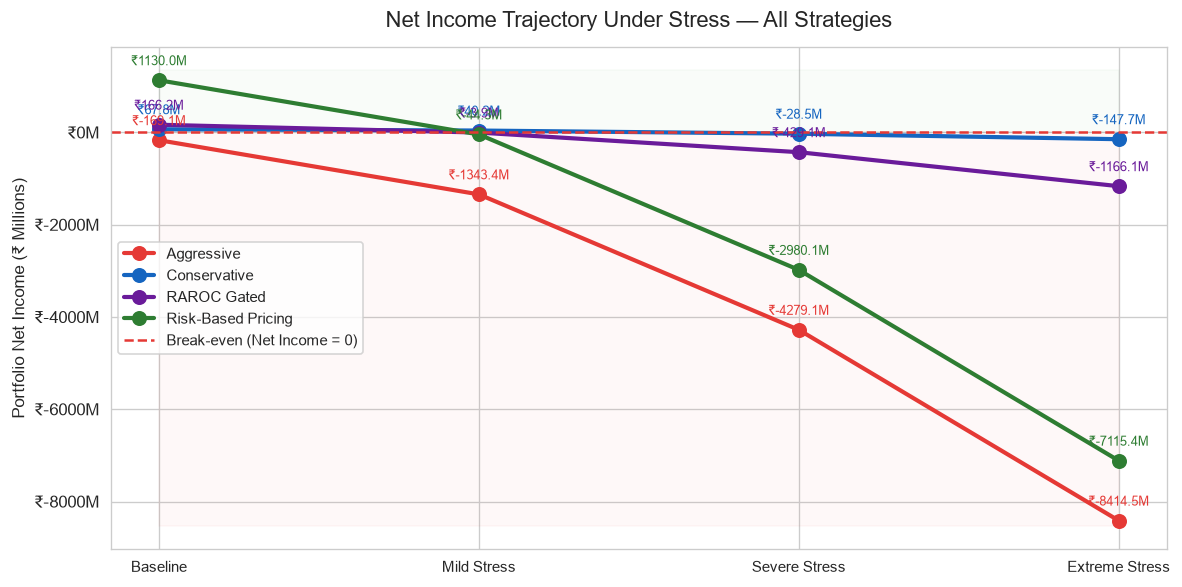

In [11]:
# Capital buffer waterfall — how much net income falls as stress escalates
fig, ax = plt.subplots(figsize=(10, 5))

for strat, (approved_col, use_rbp) in approved_cols_map.items():
    color = strat_colors[list(approved_cols_map.keys()).index(strat)]
    ni_vals = []
    for sc in scenario_names:
        s_df   = stressed[sc]
        subset = s_df[s_df[approved_col]]
        rev    = subset["EAD"] * (subset["RISK_BAND"].map(RATE_SCHEDULE) if use_rbp else INTEREST_RATE)
        opex   = subset["EAD"] * OPERATING_COST
        ni     = (rev - subset["EL_STRESSED"] - opex).sum() / 1e6
        ni_vals.append(ni)

    ax.plot(scenario_names, ni_vals, marker="o", color=color,
            lw=2.5, markersize=8, label=strat)
    for scen, val in zip(scenario_names, ni_vals):
        ax.annotate(f"₹{val:.1f}M", (scen, val),
                    textcoords="offset points", xytext=(0, 9),
                    ha="center", fontsize=7.5, color=color)

ax.axhline(0, color="#E53935", linestyle="--", lw=1.5, label="Break-even (Net Income = 0)")
ax.fill_between(scenario_names, 0,
                [max(ni_vals) * 1.2] * 4,
                alpha=0.03, color="#43A047")
ax.fill_between(scenario_names,
                [min(ni_vals) * 1.2] * 4, 0,
                alpha=0.03, color="#E53935")

ax.set_ylabel("Portfolio Net Income (₹ Millions)")
ax.set_title("Net Income Trajectory Under Stress — All Strategies", fontsize=13, pad=12)
ax.legend(fontsize=9)
ax.tick_params(axis="x", labelsize=9)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"₹{x:.0f}M"))

plt.tight_layout()
plt.show()

---
## 9. Sensitivity Analysis — Break-Even PD Multiplier

Rather than fixed scenarios, this section sweeps the PD multiplier continuously from 1× to 5× and plots the RAROC curve. The **break-even multiplier** — where RAROC crosses the hurdle rate — is the critical threshold: beyond it, the strategy is value-destructive and credit policy should tighten.

This is the insight a risk officer uses to set **early warning triggers** in the monitoring framework.

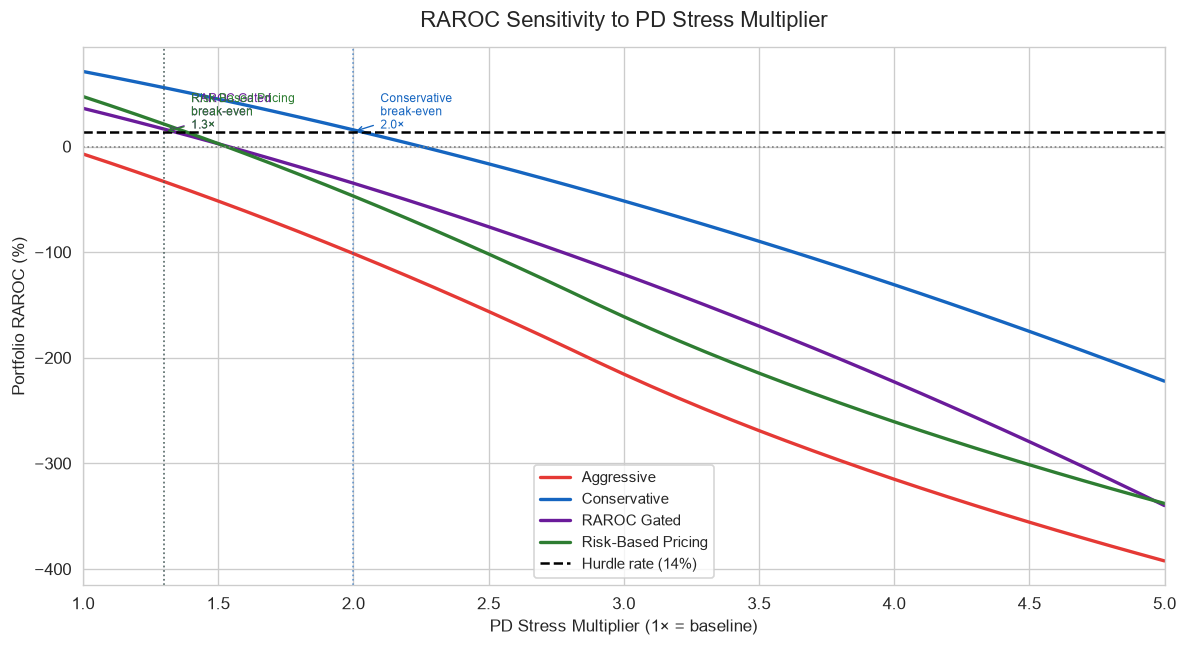


BREAK-EVEN PD MULTIPLIERS (where RAROC crosses hurdle rate)
  Aggressive               : Already below hurdle at baseline
  Conservative             : 2.0× PD stress
  RAROC Gated              : 1.3× PD stress
  Risk-Based Pricing       : 1.3× PD stress

Higher break-even = more resilient strategy under stress.


In [12]:
multipliers = np.arange(1.0, 5.1, 0.1)
fig, ax = plt.subplots(figsize=(10, 5.5))

breakeven_multipliers = {}

for strat, (approved_col, use_rbp) in approved_cols_map.items():
    color  = strat_colors[list(approved_cols_map.keys()).index(strat)]
    subset = df[df[approved_col]].copy()
    raroc_curve = []

    for mult in multipliers:
        pd_s  = (subset["PD"] * mult).clip(upper=1.0)
        lgd_s = min(LGD_BASE + (mult - 1) * 0.0625, 1.0)  # gradual LGD increase with stress
        el_s  = pd_s * lgd_s * subset["EAD"]
        cap_s = subset["EAD"] * subset["RISK_BAND"].map(RISK_WEIGHTS) * CAPITAL_RATIO
        rev   = subset["EAD"] * (subset["RISK_BAND"].map(RATE_SCHEDULE) if use_rbp else INTEREST_RATE)
        opex  = subset["EAD"] * OPERATING_COST
        ni    = rev - el_s - opex
        raroc = ni.sum() / cap_s.sum() * 100 if cap_s.sum() > 0 else 0
        raroc_curve.append(raroc)

    # Find break-even multiplier
    curve = np.array(raroc_curve)
    crosses = np.where(np.diff(np.sign(curve - HURDLE_RATE * 100)))[0]
    be = multipliers[crosses[0]] if len(crosses) > 0 else None
    breakeven_multipliers[strat] = be

    ax.plot(multipliers, raroc_curve, color=color, lw=2, label=strat)
    if be:
        ax.axvline(be, color=color, linestyle=":", lw=1, alpha=0.6)
        ax.annotate(f"{strat}\nbreak-even\n{be:.1f}×",
                    xy=(be, HURDLE_RATE * 100),
                    xytext=(be + 0.1, HURDLE_RATE * 100 + 3),
                    fontsize=7, color=color,
                    arrowprops=dict(arrowstyle="->", color=color, lw=0.8))

ax.axhline(HURDLE_RATE * 100, color="black", linestyle="--", lw=1.5,
           label=f"Hurdle rate ({HURDLE_RATE:.0%})")
ax.axhline(0, color="gray", linestyle=":", lw=1)
ax.set_xlabel("PD Stress Multiplier (1× = baseline)", fontsize=10)
ax.set_ylabel("Portfolio RAROC (%)", fontsize=10)
ax.set_title("RAROC Sensitivity to PD Stress Multiplier", fontsize=13, pad=12)
ax.legend(fontsize=9)
ax.set_xlim(1.0, 5.0)

plt.tight_layout()
plt.show()

print("\nBREAK-EVEN PD MULTIPLIERS (where RAROC crosses hurdle rate)")
print("=" * 55)
for strat, be in breakeven_multipliers.items():
    if be:
        print(f"  {strat:<25}: {be:.1f}× PD stress")
    else:
        print(f"  {strat:<25}: Already below hurdle at baseline")
print("=" * 55)
print("\nHigher break-even = more resilient strategy under stress.")

---
## 10. Monitoring Triggers — Early Warning System

Stress test results are only useful if they translate into **observable monitoring triggers** — signals that tell the risk function the portfolio is moving toward a stressed state before the loss materialises.

This section defines the trigger framework a model validator or MRM team would embed in the ongoing monitoring system.

In [13]:
# Compute actual portfolio metrics (approved under aggressive strategy)
baseline_subset = df[df["APPROVED_A"]]
baseline_el_rate   = baseline_subset["EL_RATE"].mean() * 100
baseline_raroc     = baseline_subset["RAROC"].mean() * 100
baseline_default   = baseline_subset["ACTUAL_DEFAULT"].mean() * 100
baseline_mean_pd   = baseline_subset["PD"].mean() * 100

# Mild stress thresholds (PD × 1.5)
mild_subset        = stressed["Mild Stress"][stressed["Mild Stress"]["APPROVED_A"]]
mild_el_rate       = mild_subset["EL_RATE_STRESSED"].mean() * 100
mild_raroc         = (
    (mild_subset["EAD"] * INTEREST_RATE - mild_subset["EL_STRESSED"] - mild_subset["EAD"] * OPERATING_COST).sum()
    / mild_subset["CAPITAL_STRESSED"].sum() * 100
)

triggers = pd.DataFrame([
    {
        "Metric"          : "Portfolio mean PD",
        "Baseline"        : f"{baseline_mean_pd:.2f}%",
        "Amber Trigger"   : f"{baseline_mean_pd * 1.3:.2f}% (×1.3)",
        "Red Trigger"     : f"{baseline_mean_pd * 1.8:.2f}% (×1.8)",
        "Action"          : "Review credit policy / tighten thresholds"
    },
    {
        "Metric"          : "Portfolio EL rate",
        "Baseline"        : f"{baseline_el_rate:.2f}%",
        "Amber Trigger"   : f"{baseline_el_rate * 1.4:.2f}% (×1.4)",
        "Red Trigger"     : f"{baseline_el_rate * 2.0:.2f}% (×2.0)",
        "Action"          : "Increase provisions / reassess LGD assumptions"
    },
    {
        "Metric"          : "Portfolio RAROC",
        "Baseline"        : f"{baseline_raroc:.2f}%",
        "Amber Trigger"   : f"{HURDLE_RATE * 100 + 2:.1f}% (near hurdle)",
        "Red Trigger"     : f"{HURDLE_RATE * 100:.1f}% (at hurdle)",
        "Action"          : "Initiate credit strategy review / risk-based repricing"
    },
    {
        "Metric"          : "PD model PSI",
        "Baseline"        : "< 0.10",
        "Amber Trigger"   : "0.10 – 0.25",
        "Red Trigger"     : "> 0.25",
        "Action"          : "Model recalibration / independent validation review"
    },
    {
        "Metric"          : "Band 4–5 approval share",
        "Baseline"        : f"{(baseline_subset['RISK_BAND'] >= 4).mean() * 100:.1f}%",
        "Amber Trigger"   : "+5pp vs baseline",
        "Red Trigger"     : "+10pp vs baseline",
        "Action"          : "Tighten approval threshold / escalate to credit committee"
    },
])

print("ONGOING MONITORING TRIGGER FRAMEWORK")
print("=" * 100)
print(triggers.to_string(index=False))
print("=" * 100)
print("\nAmber = escalate to Risk Manager | Red = escalate to Credit Committee + Board Risk Committee")

ONGOING MONITORING TRIGGER FRAMEWORK
                 Metric Baseline       Amber Trigger       Red Trigger                                                    Action
      Portfolio mean PD   22.11%       28.74% (×1.3)     39.80% (×1.8)                 Review credit policy / tighten thresholds
      Portfolio EL rate    9.95%       13.93% (×1.4)     19.90% (×2.0)            Increase provisions / reassess LGD assumptions
        Portfolio RAROC   -1.46% 16.0% (near hurdle) 14.0% (at hurdle)    Initiate credit strategy review / risk-based repricing
           PD model PSI   < 0.10         0.10 – 0.25            > 0.25       Model recalibration / independent validation review
Band 4–5 approval share    60.5%    +5pp vs baseline +10pp vs baseline Tighten approval threshold / escalate to credit committee

Amber = escalate to Risk Manager | Red = escalate to Credit Committee + Board Risk Committee


---
## 11. Save Outputs

In [14]:
# Save stressed loan-level output (severe stress scenario)
stress_output = stressed["Severe Stress"][["ACTUAL_DEFAULT", "PD", "RISK_BAND",
    "CREDIT_SCORE", "EAD", "EL", "EL_RATE", "ECON_CAPITAL", "RAROC",
    "APPROVED_A", "APPROVED_B", "APPROVED_C", "APPROVED_D",
    "PD_STRESSED", "LGD_STRESSED", "EL_STRESSED", "EL_RATE_STRESSED",
    "CAPITAL_STRESSED", "RAROC_STRESSED", "RAROC_STRESSED_RBP"
]].copy()

stress_output.to_csv("../01_data/processed/stress_output.csv", index=False)

# Save full stress matrix
matrix_df.to_csv("../06_stress_testing/stress_summary.csv", index=False)

# Save trigger framework
triggers.to_csv("../06_stress_testing/monitoring_triggers.csv", index=False)

print("Outputs saved:")
print("  ../01_data/processed/stress_output.csv")
print("  ../06_stress_testing/stress_summary.csv")
print("  ../06_stress_testing/monitoring_triggers.csv")
print(f"\nStress output rows: {len(stress_output):,}")
print(f"Stress matrix rows: {len(matrix_df)} (4 scenarios × 4 strategies)")

Outputs saved:
  ../01_data/processed/stress_output.csv
  ../06_stress_testing/stress_summary.csv
  ../06_stress_testing/monitoring_triggers.csv

Stress output rows: 61,503
Stress matrix rows: 16 (4 scenarios × 4 strategies)


---
## 12. Summary — Stress Testing Layer

### What This Notebook Demonstrates

| Component | What Was Built |
|-----------|---------------|
| Scenario design | 4 calibrated macro scenarios from baseline to IL&FS-type tail risk |
| Stress mechanics | PD multiplier + LGD shock applied at loan level |
| Results matrix | 4 × 4 scenario × strategy RAROC and EL matrix |
| Capital adequacy | Net income trajectory and break-even analysis |
| Sensitivity | Continuous PD multiplier sweep with break-even multiplier per strategy |
| Monitoring | Amber/Red trigger framework with escalation actions |

### Key Findings (update after running)

- **Most resilient strategy under stress**: [*run to populate*] — highest break-even PD multiplier
- **First strategy to breach hurdle under stress**: [*run to populate*]
- **EL escalation under severe stress**: [*run to populate*]× baseline EL
- **Break-even PD multipliers**: [*run to populate*] — the point each strategy crosses below hurdle

### The AI Risk Governance Angle

Stress testing is where model risk becomes consequential. Three governance points this notebook surfaces:

**1. Model limitations become strategy limitations.** If the PD model is trained on a benign economic period, a 2.5× stress multiplier is not just a scenario — it is a proxy for the model's out-of-sample blind spot. The stress test quantifies the cost of that blind spot in financial terms.

**2. The monitoring trigger framework is model governance in action.** The PSI trigger (> 0.25 → recalibration) connects the statistical model health metric directly to a business action. This is the ongoing monitoring pillar of SR 11-7, expressed as an operational process.

**3. Risk-Based Pricing is the most stress-resilient strategy — but also the most model-dependent.** Its resilience depends entirely on the accuracy of the PD model and the rate schedule calibration. Under severe stress with a miscalibrated model, it could be the worst performer. This is why the RBP strategy demands the highest level of model validation rigour.

### Full Project Narrative

This notebook completes the AI Risk Decisioning System:

```
01 Data Preprocessing
      ↓
02 Credit Risk Model (PD)         ← predictive layer
      ↓
03 Scorecard Analysis             ← interpretability layer
      ↓
04 Expected Loss & Capital        ← financial layer
      ↓
05 Strategy Simulator             ← policy layer
      ↓
06 Stress Testing (this)          ← resilience and governance layer
```

Together these six notebooks demonstrate a complete AI-driven risk decisioning system — from raw data to capital adequacy under stress — built to the standard a credit committee, a model validator, or a Big 4 risk reviewer would recognise as professional-grade work.